### Day 1 - Load and Inspect
  * Load the CSV into Pandas
  * Print the shape, columns, and first few rows
  * Identify what each column means
  * Check for missing values

In [2]:
import pandas as pd

In [3]:
fire_df =  pd.read_csv('../data/fire_archive.csv')

In [4]:
print(f"Shape: {fire_df.shape}")

Shape: (4685568, 15)


In [5]:
fire_df.columns.tolist()

['latitude',
 'longitude',
 'brightness',
 'scan',
 'track',
 'acq_date',
 'acq_time',
 'satellite',
 'instrument',
 'confidence',
 'version',
 'bright_t31',
 'frp',
 'daynight',
 'type']

In [6]:
fire_df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-13.2704,-45.5736,311.9,1.1,1.0,2023-01-01,128,Terra,MODIS,84,61.03,291.1,12.2,N,0
1,-13.2689,-45.5637,323.4,1.1,1.0,2023-01-01,128,Terra,MODIS,100,61.03,291.7,23.8,N,0
2,-13.3373,-44.1169,303.3,1.3,1.1,2023-01-01,128,Terra,MODIS,54,61.03,292.5,7.0,N,0
3,-13.2674,-45.5538,320.0,1.1,1.0,2023-01-01,128,Terra,MODIS,100,61.03,291.2,20.0,N,0
4,41.1623,123.0031,303.4,1.3,1.1,2023-01-01,210,Terra,MODIS,56,61.03,270.7,14.8,D,2


In [7]:
fire_df.isnull().sum()

latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_t31    0
frp           0
daynight      0
type          0
dtype: int64

In [ ]:
print(f"Fire types:")
print(fire_df['type'].value_counts())
# 0 - Vegetation fires
# 1 - Active volcano
# 2 - Other static land course
# 3 - Offshore detection

Fire types:
type
0    4476178
2     183693
3      19468
1       6229
Name: count, dtype: int64


In [9]:
print(f"\nConfidence range:")
print(fire_df['confidence'].value_counts()) # A percentage of how certain the satellite is that a detection is real fire.


Confidence range:
confidence
100    353538
75      91679
71      91035
69      90513
70      90485
        ...  
5         884
4         649
3         460
2         296
1         145
Name: count, Length: 101, dtype: int64


### Day 2 - Clean the data
  * Convert date columns to datetime format
  * Filter to continental US if needed
  * Handle null values in key columns like frp, brightness, and confidence
  * Drop duplicates

In [10]:
# Filter to type 0 and confidence 75 or above
fire_df = fire_df[(fire_df['type'] == 0) & (fire_df['confidence'] >= 75)]

In [11]:
fire_df.shape

(1758504, 15)

In [12]:
# Drop the columns scan, track, version, and instrument
# Scan - the horizontal satellite pixel size in kilometers.
# Track - the vertical size of the satellite pizel in kilometers (tells you how big the detection pixels are)
# Version - the version of the fire detection software (algorithm) that processed the data
# Instrument - the specific sensor on the satellite made the detection
fire_df = fire_df.drop(columns=['scan', 'track', 'version', 'instrument'])

In [13]:
# Convert acq_date to datetime format
fire_df['acq_date'] = pd.to_datetime(fire_df['acq_date'], format="%Y-%m-%d")

In [14]:
# Save as fires_clean.csv in your data/ folder
fire_df.to_csv("../data/cleaned_fire_archive.csv", index=False)

### Day 3 - Explore the Data
  * Summary statistics on key columns
  * Distribution of fire intensity (frp and brightness)
  * How many detections per month
  * Which regions have the most activity

In [15]:
cleaned_fire_df =  pd.read_csv('../data/cleaned_fire_archive.csv', parse_dates=['acq_date'])

In [16]:
# 1. Summary statistics on brightness, frp, and confidence
cleaned_fire_df[['brightness', 'frp', 'confidence']].describe()

,brightness,frp,confidence
count,1.758504e+06,1.758504e+06,1.758504e+06
mean,3.401190e+02,9.107105e+01,8.758821e+01
std,2.174496e+01,1.983366e+02,8.580432e+00
min,3.084000e+02,0.000000e+00,7.500000e+01
25%,3.273000e+02,2.430000e+01,8.000000e+01
50%,3.355000e+02,4.250000e+01,8.600000e+01
75%,3.471000e+02,8.700000e+01,9.600000e+01
max,5.105000e+02,1.399420e+04,1.000000e+02


<Axes: ylabel='Frequency'>

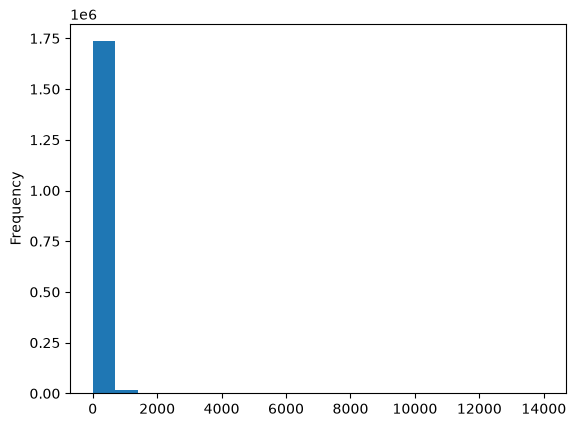

In [17]:
# 2. Distribution of fire intensity - how spread out are frp and brightness values
cleaned_fire_df['frp'].plot(kind='hist', bins=20) # frp = "Fire Radiative Power" (measures the rate of energy released by a fire in MW - Megawatts)

<Axes: ylabel='Frequency'>

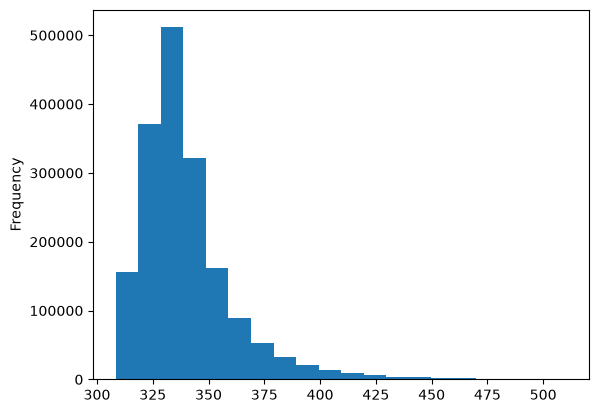

In [18]:
# positively skewed
# brightness (measures the temperature of the fire pixel in Kelvin detected by satellite sensor)
cleaned_fire_df['brightness'].plot(kind='hist', bins=20) # higher brightness = hotter fire, lower brightness = cooler fire, less intense

In [19]:
# 3. Count detections by month - is there a clear fire season peak

# Extract the month number from acq_date into a new column called month
# Group the dataframe by month and count the number of rows in each group
# Sort by month number so January through December appear in order

In [20]:
cleaned_fire_df['month'] = cleaned_fire_df['acq_date'].dt.month

In [21]:
cleaned_fire_df

,latitude,longitude,brightness,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,month
0,-13.2704,-45.5736,311.9,2023-01-01,128,Terra,84,291.1,12.2,N,0,1
1,-13.2689,-45.5637,323.4,2023-01-01,128,Terra,100,291.7,23.8,N,0,1
2,-13.2674,-45.5538,320.0,2023-01-01,128,Terra,100,291.2,20.0,N,0,1
3,43.1262,-4.0911,316.0,2023-01-01,221,Aqua,92,273.7,20.4,N,0,1
4,-20.9621,116.4452,339.8,2023-01-01,227,Terra,81,309.1,37.4,D,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1758499,31.1620,48.0582,316.4,2023-12-31,2301,Aqua,93,283.8,18.8,N,0,12
1758500,31.1464,47.6269,320.0,2023-12-31,2301,Aqua,99,282.8,23.8,N,0,12
1758501,29.0130,47.7473,312.8,2023-12-31,2302,Aqua,86,283.1,15.8,N,0,12
1758502,25.6172,50.0836,312.8,2023-12-31,2303,Aqua,86,285.0,16.1,N,0,12


In [22]:
cleaned_fire_df.groupby('month').size()

month
1     102262
2     109644
3      99557
4     102286
5     110501
6     125446
7     217703
8     248155
9     220976
10    195504
11    118050
12    108420
dtype: int64

In [23]:
cleaned_fire_df.groupby('month').size().sort_values(ascending=False)

month
8     248155
9     220976
7     217703
10    195504
6     125446
11    118050
5     110501
2     109644
12    108420
4     102286
1     102262
3      99557
dtype: int64

#### July, August, September were the 3 months in 2023 that consecutively exceeded 200,000 fire detections per month.

### Day 4 - Plot Fire Detections on a Map by Fire Radiative Power

In [24]:
# Filter your dataset to July, August, September
cleaned_fire_df = cleaned_fire_df[(cleaned_fire_df['month'] == 7) | (cleaned_fire_df['month'] == 8) | (cleaned_fire_df['month'] == 9)]

In [25]:
cleaned_fire_df.head()

,latitude,longitude,brightness,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,month
649696,-12.9526,141.7010,344.5,2023-07-01,2,Terra,93,294.2,177.4,D,0,7
649697,-12.9449,141.7092,323.0,2023-07-01,2,Terra,79,293.3,62.6,D,0,7
649698,-12.4348,141.8997,326.8,2023-07-01,2,Terra,82,294.2,74.3,D,0,7
649699,-23.4761,148.1693,320.9,2023-07-01,5,Terra,80,292.3,18.5,D,0,7
649700,-23.4668,148.1707,325.3,2023-07-01,5,Terra,84,292.7,23.2,D,0,7


In [26]:
import folium

In [27]:
# Create a Folium map object centered on the United States
m = folium.Map(location=[35, -105], zoom_start=5) 

In [28]:
from matplotlib.colors import Normalize, to_hex
from matplotlib import cm

In [29]:
min_frp, max_frp = cleaned_fire_df['frp'].min(), cleaned_fire_df['frp'].max()

In [30]:
normalizer = Normalize(min_frp, max_frp)

In [31]:
cleaned_fire_df_sample = cleaned_fire_df.sample(10000, random_state=1234)

In [32]:
for index, row in cleaned_fire_df_sample.iterrows():
    latitude_deg = row['latitude']
    longitude_deg = row['longitude']
    fire_energy_output = row['frp'] # energy output of the fire measured in megawatts
    normalized_frp = normalizer(fire_energy_output) # get a value between 0 and 1
    rgba_tuple = cm.YlOrRd(normalized_frp)
    hex_code_string = to_hex(rgba_tuple)
    folium.CircleMarker(location=[latitude_deg, longitude_deg], radius=4, color=hex_code_string, fill=True).add_to(m)

In [33]:
# Save the map as an HTMl file and open it in your browser
m.save("fire_detection_visualization.html")

#### Identify geographic clusters visually - where are the most intense fire concentrations?
1. Central and Southern Africa
2. South America
3. America and Australia
4. Russia
5. Eastern Europe
6. North Africa + Middle Eastern

### Day 5 - Temporal Analysis

In [35]:
import matplotlib.pyplot as plt

In [36]:
# 1. Plot fire detections by month as a bar chart to visualize the fire season peak

In [52]:
months = cleaned_fire_df['month'].unique().tolist()

In [50]:
fire_detections = cleaned_fire_df.groupby('month').size().tolist()

In [61]:
numberToMonth = { 1: "January",
                  2: "February", 
                  3: "March",
                  4: "April",
                  5: "May",
                  6: "June",
                  7: "July",
                  8: "August",
                  9: "September",
                  10: "October",
                  11: "November",
                  12: "December"
                  }

In [ ]:
fire_detections

[217703, 248155, 220976]

In [82]:
real_months = [numberToMonth[month] for month in months]

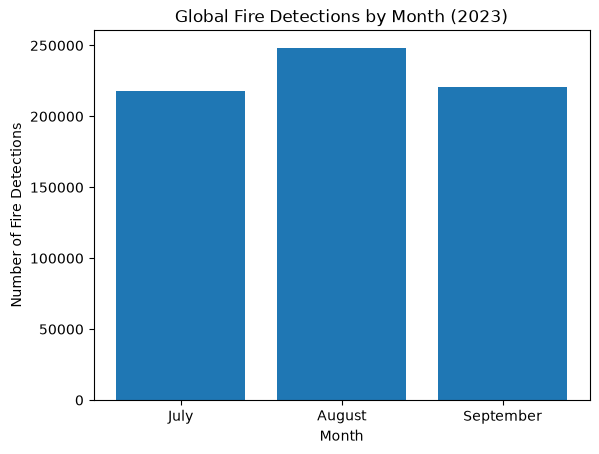

In [109]:
plt.bar(months, fire_detections)
plt.xticks(months, real_months)
plt.title('Global Fire Detections by Month (2023)')
plt.xlabel('Month')
plt.ylabel('Number of Fire Detections')
plt.show()

#### 2. Plot fire detections over time by week to see finer grained trends

In [ ]:
# Extract the week number from acq_date into a newe column called week
cleaned_fire_df['week'] = cleaned_fire_df['acq_date'].dt.isocalendar().week

In [ ]:
# Group the dataframe by week and count the number of detections in each group
cleaned_fire_df.groupby('week').size()

week
26     9983
27    47446
28    55116
29    47732
30    50009
31    51116
32    55631
33    52291
34    69178
35    54434
36    52417
37    53954
38    54530
39    32997
dtype: int64

In [108]:
weeks = cleaned_fire_df['week'].unique().tolist()
detections = cleaned_fire_df.groupby('week').size().tolist()

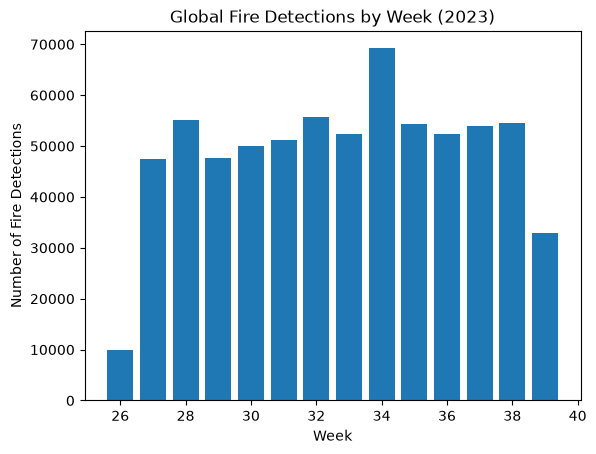

In [110]:
# Plot as a vertical bar chart with week number on the x-axis and detection count on the y-axis
plt.bar(weeks, detections)
plt.title('Global Fire Detections by Week (2023)')
plt.xlabel('Week')
plt.ylabel('Number of Fire Detections')
plt.show()

#### 3. Look at how average frp changes by month - are the most intesnse fire also in July through September

In [111]:
cleaned_fire_df.head()

,latitude,longitude,brightness,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,month,week
649696,-12.9526,141.7010,344.5,2023-07-01,2,Terra,93,294.2,177.4,D,0,7,26
649697,-12.9449,141.7092,323.0,2023-07-01,2,Terra,79,293.3,62.6,D,0,7,26
649698,-12.4348,141.8997,326.8,2023-07-01,2,Terra,82,294.2,74.3,D,0,7,26
649699,-23.4761,148.1693,320.9,2023-07-01,5,Terra,80,292.3,18.5,D,0,7,26
649700,-23.4668,148.1707,325.3,2023-07-01,5,Terra,84,292.7,23.2,D,0,7,26


In [125]:
months = cleaned_fire_df['month'].unique().tolist()
average_monthly_frp = cleaned_fire_df.groupby('month')['frp'].mean().tolist()

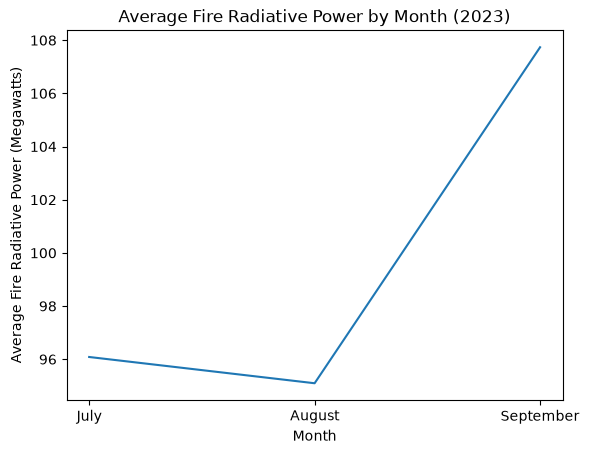

In [127]:
plt.plot(months, average_monthly_frp)
plt.title("Average Fire Radiative Power by Month (2023)")
plt.xticks(months, real_months)
plt.xlabel("Month")
plt.ylabel("Average Fire Radiative Power (Megawatts)")
plt.show()

#### 4. Identify peak fire activity periods that will inform your case study selection on Day 6


* August was the month with the highest fire detection count
* Week  34 was the week that had the sharpest spike in fire detections
* September was the month with the highest average FRP

### Day 6 - Pick Your Case Study Fire
  * Choose one well-documented 2023 wildfire to validate against later
  * Research its start date, location, and final perimeter

In [129]:
cleaned_fire_df.head()

,latitude,longitude,brightness,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,month,week
649696,-12.9526,141.7010,344.5,2023-07-01,2,Terra,93,294.2,177.4,D,0,7,26
649697,-12.9449,141.7092,323.0,2023-07-01,2,Terra,79,293.3,62.6,D,0,7,26
649698,-12.4348,141.8997,326.8,2023-07-01,2,Terra,82,294.2,74.3,D,0,7,26
649699,-23.4761,148.1693,320.9,2023-07-01,5,Terra,80,292.3,18.5,D,0,7,26
649700,-23.4668,148.1707,325.3,2023-07-01,5,Terra,84,292.7,23.2,D,0,7,26


In [131]:
# 1. Filter your cleaned dataframe to weeks 34 through weeks 39
filtered_fire_df = cleaned_fire_df[(cleaned_fire_df['week'] >= 34) & (cleaned_fire_df['week'] <= 39)] 

In [134]:
# 2. Round latitude and longitude to one decimal place to create geographic clusters
filtered_fire_df['rounded_latitude'] = filtered_fire_df['latitude'].round(1)
filtered_fire_df['rounded_longitude'] = filtered_fire_df['longitude'].round(1)

In [ ]:
# 3. Group by the rounded latitude and longitude, calculate the total detection count and average FRP for each cluster
detection_count = filtered_fire_df.groupby(['rounded_latitude', 'rounded_longitude']).size()
average_frp = filtered_fire_df.groupby(['rounded_latitude', 'rounded_longitude'])['frp'].mean()

detection_count

rounded_latitude  rounded_longitude
-46.4              169.4                3
-45.7             -70.4                 3
-45.3              170.3                1
                   170.4                1
-45.0              170.3                1
                                       ..
 71.2              71.7                 1
                   71.8                12
 71.3              71.8                 4
                   72.0                 2
                   72.1                 1
Length: 59028, dtype: int64

In [139]:
type(detection_count)

pandas.Series

In [138]:
average_frp

rounded_latitude  rounded_longitude
-46.4              169.4               31.900000
-45.7             -70.4                48.366667
-45.3              170.3               28.100000
                   170.4               59.400000
-45.0              170.3               68.600000
                                         ...    
 71.2              71.7                44.800000
                   71.8                27.075000
 71.3              71.8                18.175000
                   72.0                55.450000
                   72.1                38.000000
Name: frp, Length: 59028, dtype: float64

In [140]:
type(average_frp)

pandas.Series

In [141]:
hotspots = pd.concat([detection_count, average_frp], axis=1)

In [145]:
hotspots.columns

Index([0, 'frp'], dtype='object')

In [146]:
hotspots = hotspots.rename(columns={0:'detection_count', 'frp': 'average_frp'})

In [149]:
hotspots

detection_count  average_frp
rounded_latitude rounded_longitude                              
-46.4             169.4                           3    31.900000
-45.7            -70.4                            3    48.366667
-45.3             170.3                           1    28.100000
                  170.4                           1    59.400000
-45.0             170.3                           1    68.600000
...                                             ...          ...
 71.2             71.7                            1    44.800000
                  71.8                           12    27.075000
 71.3             71.8                            4    18.175000
                  72.0                            2    55.450000
                  72.1                            1    38.000000

[59028 rows x 2 columns]

In [150]:
# 5. Sort by average FRP descending
sorted_average_frp_desc = hotspots.sort_values(by='average_frp', ascending=False)

In [151]:
sorted_average_frp_desc

,,detection_count,average_frp
rounded_latitude,rounded_longitude,,
59.9,-119.8,10,4014.710
60.7,-120.1,4,2352.025
-20.3,135.6,25,2001.200
-21.5,23.5,4,1851.425
-21.0,124.1,8,1834.875
...,...,...,...
-23.8,23.1,6,0.000
28.3,-96.5,1,0.000
61.4,-110.2,3,0.000


In [ ]:
# 6. Print the top 10 or 20 clusters

In [152]:
sorted_average_frp_desc.head(20)

,,detection_count,average_frp
rounded_latitude,rounded_longitude,,
59.9,-119.8,10,4014.710000
60.7,-120.1,4,2352.025000
-20.3,135.6,25,2001.200000
-21.5,23.5,4,1851.425000
-21.0,124.1,8,1834.875000
59.9,-119.9,18,1739.772222
-28.7,25.9,8,1684.625000
-18.6,137.1,25,1549.020000
58.3,-118.3,100,1500.187000


### Summary
* In Week 1, I did data exploration and visualization. I cleaned my data by converting date columns to datetime format and filtered to fires that are of type 0 fires (vegetation fires) and confidence levels of 75 and above. I explored features in the dataset such as brightness, fire radiative power, and satellite confidence level and visualized them using matplotlib to figure out when in the calendar year of 2023 the most fires had been detected. I ended up picking the top 3 months that had the highest fire detections of the whole year namely July, August, and September. I took a random sample of 10000 rows of the detected fires from July, August, and September and plotted those fires based on latitude, longitude, and the normalized fire intensity on a map. I did some temporal analysis on the cleaned fire dataset to analyze trends in the number of fire detections in each month, the number of fire detections in each one of the weeks in those months, and the average fire radiative power in each month. I computed the total fire detection count and the average FRP through grouping by rounded latitude and longitude for each one of the rows in my dataframe for weeks 34 to 39 in my dataset to figure out what the 20 most intense fires were in that time frame based on the highest average fire intensities based on latitude and longitude cluster.